# Cosmic-String Power Spectrum

This notebook computes and plots theory power spectra using the `strings` package.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "strings").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from strings import compute_cl

In [2]:
ell = np.arange(2, 500,2)
parameter_sets = [
    {"G_mu": 2.5e-5, "P": 1.0, "label": r"$G\mu=2.5\times 10^{-5}, P=1$"},
    {"G_mu": 5.0e-5, "P": 1.0, "label": r"$G\mu=5.0\times 10^{-5}, P=1$"},
    {"G_mu": 5.0e-5, "P": 1.0e-1, "label": r"$G\mu=5.0\times 10^{-5}, P=10^{-1}$"},
]

spectra = []
for params in parameter_sets:
    cl = compute_cl(
        params["G_mu"],
        params["P"],
        ell_arr=ell,
        n_k=48,
        n_chi=1024,
        k_min=1.0e-4,
        k_max=1.0e-1,
    )
    spectra.append((params["label"], cl))

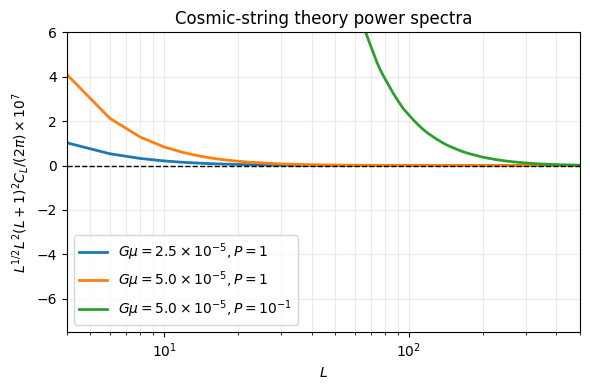

In [3]:
plot_factor = np.sqrt(ell) * ell**2 * (ell + 1.0) ** 2 / (2.0 * np.pi) * 1.0e7

plt.figure(figsize=(6,4))
for label, cl in spectra:
    scaled_cl = plot_factor * cl
    plt.plot(ell, scaled_cl, linewidth=2, label=label)

plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.semilogx()
plt.xlim(4, 500)
plt.ylim(-7.5, 6.0)
plt.xlabel(r"$L$")
plt.ylabel(r"$L^{1/2} L^2 (L+1)^2 C_L / (2\pi) \times 10^{7}$")
plt.title("Cosmic-string theory power spectra")
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()